In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#Funciones auxiliares sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score #Metricas
from sklearn.utils import shuffle 


#Gradient Boosting
import lightgbm as lgb


# Configuramos el estilo de las visualizaciones
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

breed_df = pd.read_csv('C:/Users/GWF/Documents/GitHub/UA_MDM_Labo2/input/petfinder-adoption-prediction/breed_labels.csv')
color_df = pd.read_csv('C:/Users/GWF/Documents/GitHub/UA_MDM_Labo2/input/petfinder-adoption-prediction/color_labels.csv')
state_df = pd.read_csv('C:/Users/GWF/Documents/GitHub/UA_MDM_Labo2/input/petfinder-adoption-prediction/state_labels.csv')

# Definimos la ruta
ruta_archivo = 'C:/Users/GWF/Documents/GitHub/UA_MDM_Labo2/input/petfinder-adoption-prediction/train/train.csv'

# Intentamos leer con latin-1

# Agregamos el parámetro sep=';'
train_df = pd.read_csv(ruta_archivo, sep=',', encoding='latin-1')


In [26]:
SEED = 42 #Semilla de procesos aleatorios (para poder replicar exactamente al volver a correr un modelo)
TEST_SIZE = 0.2 #Facción para train/test= split

In [27]:
#Separo un 20% para test estratificado opr target
df_train, df_test = train_test_split(train_df,
                               test_size = TEST_SIZE,
                               random_state = SEED,
                               stratify = train_df.AdoptionSpeed)

In [28]:
import pandas as pd

# 1. Cargar el dataset original
# Asegúrate de que el archivo esté en la misma carpeta que tu notebook

def categorizar_tamano(row):
    breed = str(row['BreedName']).lower()
    pet_type = row['Type']
    
    # Gatos (Type = 2): Los clasificamos como 'Pequeño' por defecto en comparación a un perro
    if pet_type == 2:
        return 'Pequeño'
        
    # Perros (Type = 1)
    if 'mixed breed' in breed:
        return 'Mediano' # Promedio estadístico seguro para perros mestizos
        
    # A. Excepciones específicas (se evalúan antes que las reglas generales)
    excepciones_grandes = ['black russian terrier', 'airedale terrier', 'afghan hound', 'bloodhound', 'greyhound', 'irish wolfhound']
    excepciones_medianos = ['american staffordshire terrier', 'pit bull terrier', 'bull terrier', 'beagle', 'basset hound', 'whippet', 'standard schnauzer', 'cocker spaniel']
    excepciones_pequenos = ['dachshund', 'miniature schnauzer', 'toy', 'miniature']
    
    if any(exc in breed for exc in excepciones_grandes):
        return 'Grande'
    if any(exc in breed for exc in excepciones_medianos):
        return 'Mediano'
    if any(exc in breed for exc in excepciones_pequenos):
        return 'Pequeño'
        
    # B. Reglas generales por familias funcionales / palabras clave
    # La mayoría de los terriers y perros de compañía son pequeños
    keywords_pequenos = ['terrier', 'chihuahua', 'pomeranian', 'pug', 'shih tzu', 'maltese', 'pekingese', 'corgi', 'bichon', 'french bulldog', 'papillon', 'havanese', 'pinscher']
    
    # La mayoría de los pastores, cobradores, mastines y sabuesos son grandes
    keywords_grandes = ['retriever', 'shepherd', 'mastiff', 'great', 'husky', 'malamute', 'akita', 'hound', 'pointer', 'setter', 'collie', 'rottweiler', 'doberman', 'boxer', 'american bulldog', 'sheepdog', 'dane', 'bernard', 'pyrenees', 'newfoundland', 'weimaraner', 'ridgeback', 'corso', 'komondor', 'kuvasz', 'borzoi', 'dalmatian']
    
    if any(kw in breed for kw in keywords_pequenos):
        return 'Pequeño'
    if any(kw in breed for kw in keywords_grandes):
        return 'Grande'
        
    # C. Todo lo que no caiga en las reglas anteriores se asume Mediano (ej. Spaniels, Bulldogs ingleses, Spitz)
    return 'Mediano'

# 2. Aplicar la función para crear la nueva columna
breed_df['SizeCategory'] = breed_df.apply(categorizar_tamano, axis=1)

# Unimos indicando que Breed1 equivale a BreedID
df_train = df_train.merge(
    breed_df[['BreedID', 'SizeCategory']], 
    left_on='Breed1', 
    right_on='BreedID', 
    how='left'
)

df_test = df_test.merge(
    breed_df[['BreedID', 'SizeCategory']], 
    left_on='Breed1', 
    right_on='BreedID', 
    how='left'
)

# Opcional: eliminar la columna BreedID duplicada que queda tras el merge
df_train = df_train.drop(columns=['BreedID'])
df_test = df_test.drop(columns=['BreedID'])
# 3. Exportar el resultado a un nuevo archivo CSV
nuevo_archivo = 'PetFinder-BreedLabels-Sized.csv'
breed_df.to_csv(nuevo_archivo, index=False)

print(f"Archivo generado exitosamente: '{nuevo_archivo}'")
print("\nMuestra de cómo quedaron las categorías:")
display(breed_df.sample(10, random_state=42))

Archivo generado exitosamente: 'PetFinder-BreedLabels-Sized.csv'

Muestra de cómo quedaron las categorías:


,BreedID,Type,BreedName,SizeCategory
183,184,1,Pumi,Mediano
60,61,1,Chinese Crested Dog,Mediano
124,125,1,Irish Wolfhound,Grande
93,94,1,Fila Brasileiro,Mediano
63,64,1,Chocolate Labrador Retriever,Grande
9,10,1,American Staffordshire Terrier,Mediano
147,148,1,Manchester Terrier,Pequeño
158,159,1,Norfolk Terrier,Pequeño
168,169,1,Pekingese,Pequeño
33,34,1,Bloodhound,Grande


In [29]:
import pandas as pd

# 1. Cargar el dataset original
# Asegúrate de que el archivo esté en la misma carpeta que tu notebook

def categorizar_tamano(row):
    breed = str(row['BreedName']).lower()
    pet_type = row['Type']
    
    # Gatos (Type = 2): Los clasificamos como 'Pequeño' por defecto en comparación a un perro
    if pet_type == 2:
        return 'Pequeño'
        
    # Perros (Type = 1)
    if 'mixed breed' in breed:
        return 'Mediano' # Promedio estadístico seguro para perros mestizos
        
    # A. Excepciones específicas (se evalúan antes que las reglas generales)
    excepciones_grandes = ['black russian terrier', 'airedale terrier', 'afghan hound', 'bloodhound', 'greyhound', 'irish wolfhound']
    excepciones_medianos = ['american staffordshire terrier', 'pit bull terrier', 'bull terrier', 'beagle', 'basset hound', 'whippet', 'standard schnauzer', 'cocker spaniel']
    excepciones_pequenos = ['dachshund', 'miniature schnauzer', 'toy', 'miniature']
    
    if any(exc in breed for exc in excepciones_grandes):
        return 'Grande'
    if any(exc in breed for exc in excepciones_medianos):
        return 'Mediano'
    if any(exc in breed for exc in excepciones_pequenos):
        return 'Pequeño'
        
    # B. Reglas generales por familias funcionales / palabras clave
    # La mayoría de los terriers y perros de compañía son pequeños
    keywords_pequenos = ['terrier', 'chihuahua', 'pomeranian', 'pug', 'shih tzu', 'maltese', 'pekingese', 'corgi', 'bichon', 'french bulldog', 'papillon', 'havanese', 'pinscher']
    
    # La mayoría de los pastores, cobradores, mastines y sabuesos son grandes
    keywords_grandes = ['retriever', 'shepherd', 'mastiff', 'great', 'husky', 'malamute', 'akita', 'hound', 'pointer', 'setter', 'collie', 'rottweiler', 'doberman', 'boxer', 'american bulldog', 'sheepdog', 'dane', 'bernard', 'pyrenees', 'newfoundland', 'weimaraner', 'ridgeback', 'corso', 'komondor', 'kuvasz', 'borzoi', 'dalmatian']
    
    if any(kw in breed for kw in keywords_pequenos):
        return 'Pequeño'
    if any(kw in breed for kw in keywords_grandes):
        return 'Grande'
        
    # C. Todo lo que no caiga en las reglas anteriores se asume Mediano (ej. Spaniels, Bulldogs ingleses, Spitz)
    return 'Mediano'

# 2. Aplicar la función para crear la nueva columna
breed_df['SizeCategory'] = breed_df.apply(categorizar_tamano, axis=1)

# Unimos indicando que Breed1 equivale a BreedID
df_train = df_train.merge(
    breed_df[['BreedID', 'SizeCategory']], 
    left_on='Breed1', 
    right_on='BreedID', 
    how='left'
)

df_test = df_test.merge(
    breed_df[['BreedID', 'SizeCategory']], 
    left_on='Breed1', 
    right_on='BreedID', 
    how='left'
)

# Opcional: eliminar la columna BreedID duplicada que queda tras el merge
df_train = df_train.drop(columns=['BreedID'])
df_test = df_test.drop(columns=['BreedID'])
# 3. Exportar el resultado a un nuevo archivo CSV
nuevo_archivo = 'PetFinder-BreedLabels-Sized.csv'
breed_df.to_csv(nuevo_archivo, index=False)

print(f"Archivo generado exitosamente: '{nuevo_archivo}'")
print("\nMuestra de cómo quedaron las categorías:")
display(breed_df.sample(10, random_state=42))

Archivo generado exitosamente: 'PetFinder-BreedLabels-Sized.csv'

Muestra de cómo quedaron las categorías:


,BreedID,Type,BreedName,SizeCategory
183,184,1,Pumi,Mediano
60,61,1,Chinese Crested Dog,Mediano
124,125,1,Irish Wolfhound,Grande
93,94,1,Fila Brasileiro,Mediano
63,64,1,Chocolate Labrador Retriever,Grande
9,10,1,American Staffordshire Terrier,Mediano
147,148,1,Manchester Terrier,Pequeño
158,159,1,Norfolk Terrier,Pequeño
168,169,1,Pekingese,Pequeño
33,34,1,Bloodhound,Grande


In [30]:
# Creamos un diccionario para acumular las nuevas columnas rápidamente
nuevas_features = {}

# 1. Interacciones de Edad y Atributos Físicos
# Una mascota vieja y grande suele tardar más en adoptarse que una vieja y pequeña
nuevas_features['Age_x_MaturitySize'] = df_train['Age'] * df_train['MaturitySize']
nuevas_features['Age_x_MaturitySize'] = df_test['Age'] * df_test['MaturitySize']


# 2. Interacciones de Costo y Raza
# El impacto del Fee (costo) puede variar según si la raza es pura (Breed2 == 0) o no
nuevas_features['Fee_x_Breed1'] = df_train['Fee'] * df_train['Breed1']
nuevas_features['Fee_x_Breed1'] = df_test['Fee'] * df_test['Breed1']


# 3. Interacciones de Esfuerzo del Rescatista (Las más importantes según tu lista)
# ¿El rescatista que tiene muchas fotos (PhotoAmt) tiene mejor suerte con ciertas edades?
nuevas_features['Age_x_PhotoAmt'] = df_train['Age'] * df_train['PhotoAmt']
nuevas_features['Age_x_PhotoAmt'] = df_test['Age'] * df_test['PhotoAmt']

# 4. Interacciones de Salud y Cuidados
# Estar vacunado, desparasitado y esterilizado combinado
nuevas_features['Salud_Completa'] = df_train['Vaccinated'] * df_train['Dewormed'] * df_train['Sterilized']
nuevas_features['Salud_Completa'] = df_test['Vaccinated'] * df_test['Dewormed'] * df_test['Sterilized']

# 5. Ratio de Fotos por Cantidad de Mascotas
# Si hay muchos animales en la publicación (Quantity), ¿hay suficientes fotos para todos?
nuevas_features['Photos_per_Pet'] = df_train['PhotoAmt'] / (df_train['Quantity'] + 1)
nuevas_features['Photos_per_Pet'] = df_test['PhotoAmt'] / (df_test['Quantity'] + 1)

# 6. Cruces de Color y Raza (Estética)
nuevas_features['Breed_x_Color1'] = df_train['Breed1'] * df_train['Color1']
nuevas_features['Breed_x_Color1'] = df_test['Breed1'] * df_test['Color1']

# --- CONCATENACIÓN FINAL ---
print("Agregando interacciones seleccionadas al dataset...")
df_interacciones = pd.DataFrame(nuevas_features)
df_train = pd.concat([df_train, df_interacciones], axis=1)
df_test = pd.concat([df_test, df_interacciones], axis=1)

print(f"Se han agregado {len(nuevas_features)} columnas estratégicas.")
print(f"Nuevo tamaño del dataset: {df_train.shape}")

Agregando interacciones seleccionadas al dataset...
Se han agregado 6 columnas estratégicas.
Nuevo tamaño del dataset: (11994, 32)


In [31]:
def crear_variables_agregadas(df_train):
    # --- 1. Estadísticas por RescuerID (El perfil del rescatista) ---
    # Cantidad de mascotas subidas por cada rescatista
    df_train['rescu_total_pets'] = df_train.groupby('RescuerID')['RescuerID'].transform('count') #Quito rescu total pets porque restan valor
    
    # Promedio de fotos que sube este rescatista (indica calidad de perfil)
    df_train['rescu_avg_photos'] = df_train.groupby('RescuerID')['PhotoAmt'].transform('mean')
    
    # Promedio de precio que cobra este rescatista
    df_train['rescu_avg_fee'] = df_train.groupby('RescuerID')['Fee'].transform('mean')

    # --- 2. Estadísticas por Breed1 (El perfil de la raza) ---
    # ¿Qué tan común es esta raza en el dataset?
    df_train['breed_popularity'] = df_train.groupby('Breed1')['Breed1'].transform('count')
    
    # Promedio de edad para esta raza (algunas razas se abandonan más adultas)
    df_train['breed_avg_age'] = df_train.groupby('Breed1')['Age'].transform('mean')
    
    # Promedio de Fee para esta raza (hay razas que siempre son caras)
    df_train['breed_avg_fee'] = df_train.groupby('Breed1')['Fee'].transform('mean')

    # --- 3. Interacción: Rescatista x Raza ---
    # ¿Cuántas veces este rescatista trabajó con esta raza específica?
    df_train['rescu_breed_experience'] = df_train.groupby(['RescuerID', 'Breed1'])['PetID'].transform('count')

    return df_train

# Aplicamos a tu dataset
df_train = crear_variables_agregadas(df_train)
# Repetir lo mismo para el test_df si lo tenés aparte

def crear_variables_agregadas(df_test):
    # --- 1. Estadísticas por RescuerID (El perfil del rescatista) ---
    # Cantidad de mascotas subidas por cada rescatista
    df_test['rescu_total_pets'] = df_test.groupby('RescuerID')['RescuerID'].transform('count') #Quito rescu total pets porque restan valor
    
    # Promedio de fotos que sube este rescatista (indica calidad de perfil)
    df_test['rescu_avg_photos'] = df_test.groupby('RescuerID')['PhotoAmt'].transform('mean')
    
    # Promedio de precio que cobra este rescatista
    df_test['rescu_avg_fee'] = df_test.groupby('RescuerID')['Fee'].transform('mean')

    # --- 2. Estadísticas por Breed1 (El perfil de la raza) ---
    # ¿Qué tan común es esta raza en el dataset?
    df_test['breed_popularity'] = df_test.groupby('Breed1')['Breed1'].transform('count')
    
    # Promedio de edad para esta raza (algunas razas se abandonan más adultas)
    df_test['breed_avg_age'] = df_test.groupby('Breed1')['Age'].transform('mean')
    
    # Promedio de Fee para esta raza (hay razas que siempre son caras)
    df_test['breed_avg_fee'] = df_test.groupby('Breed1')['Fee'].transform('mean')

    # --- 3. Interacción: Rescatista x Raza ---
    # ¿Cuántas veces este rescatista trabajó con esta raza específica?
    df_test['rescu_breed_experience'] = df_test.groupby(['RescuerID', 'Breed1'])['PetID'].transform('count')

    return df_test

# Aplicamos a tu dataset
df_test = crear_variables_agregadas(df_test)

In [32]:
#Genero dataframes de train y test con sus respectivos targets
X_train = df_train.drop(columns=['AdoptionSpeed'])
y_train = df_train['AdoptionSpeed']

X_test = df_test.drop(columns=['AdoptionSpeed'])
y_test = df_test['AdoptionSpeed']

In [34]:
# 1. Lista de variables que DESEAMOS que sean categóricas
# (He quitado PetID, Name y RescuerID porque acordamos eliminarlas por ruido)
desired_categorical = [
    'Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 
    'SizeCategory', 'MaturitySize', 'Description', 'Has_Name'
]

# 2. Convertir a 'category' de forma segura
for col in desired_categorical:
    # Verificamos si la columna existe en X_train antes de transformarla
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        
    # Hacemos lo mismo para X_test
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')
    else:
        # Esto te avisará si alguna columna de tu lista no está en el DataFrame
        continue 

print("✅ Conversión a categóricas finalizada sin errores.")

✅ Conversión a categóricas finalizada sin errores.


In [35]:
# 1. ELIMINAR IDENTIFICADORES Y VARIABLES PROBLEMÁTICAS
# Quitamos los IDs y las variables de rescatista que restaban valor
cols_to_drop = ['PetID', 'RescuerID', 'rescu_total_pets', 'rescu_avg_fee']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# 2. TRANSFORMACIÓN DE 'NAME' (De categoría a binaria)
# Un nombre específico no ayuda, pero tener nombre o no, ¡sí!
def transform_name(df):
    # Creamos 'Has_Name': 1 si tiene nombre (no es nulo o 'None'), 0 si no
    df['Has_Name'] = df['Name'].apply(lambda x: 0 if pd.isna(x) or str(x).lower() == 'none' or str(x) == '' else 1)
    return df.drop(columns=['Name'])

X_train = transform_name(X_train)
X_test = transform_name(X_test)

# 3. POTENCIAR LO QUE FUNCIONA (Nuevas interacciones estrella)
# Edad x Salud y Edad x Raza (ya que Breed1 y Age eran tus mejores variables)
for df in [X_train, X_test]:
    # Interacción Salud Completa y Edad (los jóvenes sanos suelen salir más rápido)
    df['Age_x_Salud'] = df['Age'] * df['Salud_Completa']
    # Podrías agregar más aquí si lo deseas

# 4. ACTUALIZAR LISTA DE CATEGÓRICAS
# Eliminamos de la lista original las que ya no existen o cambiaron de tipo
categorical_cols = [c for c in categorical_cols if c not in cols_to_drop and c != 'Name']
# Agregamos la nueva variable binaria (opcional, puede ir como int)
categorical_cols.append('Has_Name')

# 5. CONVERTIR A CATEGORY (Solo las que quedaron)
for col in categorical_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

print(f"Limpieza completada. Variables restantes: {X_train.shape[1]}")

Limpieza completada. Variables restantes: 35


In [36]:
X_train

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Salud_Completa,Photos_per_Pet,Breed_x_Color1,rescu_avg_photos,breed_popularity,breed_avg_age,breed_avg_fee,rescu_breed_experience,Has_Name,Age_x_Salud
0,1,2,307,307,1,1,0,0,2,2,...,8.0,3.000000,307.0,8.000000,4754,7.558687,9.696466,1,1,16.0
1,1,12,307,0,2,2,0,0,1,1,...,2.0,1.000000,103.0,2.181818,4754,7.558687,9.696466,12,1,24.0
2,1,2,307,307,1,1,2,7,2,1,...,2.0,0.833333,614.0,5.193548,4754,7.558687,9.696466,28,1,4.0
3,1,2,307,307,1,3,0,0,2,2,...,2.0,3.000000,530.0,3.127778,4754,7.558687,9.696466,165,1,4.0
4,2,4,265,0,3,1,2,0,2,2,...,8.0,2.666667,532.0,2.000000,983,6.342828,10.769074,1,1,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11989,2,8,265,299,2,1,2,0,2,2,...,NaN,NaN,NaN,2.000000,983,6.342828,10.769074,1,1,NaN
11990,1,2,307,0,2,6,7,0,1,1,...,NaN,NaN,NaN,1.000000,4754,7.558687,9.696466,1,1,NaN
11991,1,2,307,307,1,1,0,0,2,2,...,NaN,NaN,NaN,2.000000,4754,7.558687,9.696466,4,1,NaN
11992,1,2,307,307,1,1,2,7,2,2,...,NaN,NaN,NaN,2.234234,4754,7.558687,9.696466,99,1,NaN


In [38]:
# Unificamos las columnas duplicadas por el merge (si existen)
for df in [X_train, X_test]:
    if 'SizeCategory_x' in df.columns and 'SizeCategory_y' in df.columns:
        # Rellenamos nulos de una con la otra y creamos una sola
        df['SizeCategory'] = df['SizeCategory_x'].fillna(df['SizeCategory_y'])
        # Eliminamos las versiones con _x y _y
        df.drop(columns=['SizeCategory_x', 'SizeCategory_y'], inplace=True)
    elif 'SizeCategory_x' in df.columns:
        df.rename(columns={'SizeCategory_x': 'SizeCategory'}, inplace=True)

In [39]:
# Convertir TODAS las columnas de tipo 'object' a 'category' automáticamente
for df in [X_train, X_test]:
    for col in df.columns:
        if df[col].dtype == 'object':
            # Si tiene muchos valores únicos (como Description), mejor borrarla o tratarla
            if col == 'Description':
                df.drop(columns=[col], inplace=True)
            else:
                df[col] = df[col].astype('category')

# Verificación rápida
print(X_train.dtypes[X_train.dtypes == 'object']) # Debería salir vacío

Series([], dtype: object)


In [40]:
# Solo permitimos tipos numéricos, booleanos o categorías
tipos_permitidos = ['int64', 'float64', 'bool', 'category', 'int32', 'float32']

X_train = X_train.select_dtypes(include=tipos_permitidos)
X_test = X_test.select_dtypes(include=tipos_permitidos)

# Ahora intenta el fit de nuevo
# model.fit(X_train, y_train)

In [41]:
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================================
# 1. Preparación de Datasets (Uso de validación real)
# ============================================================================
# Es fundamental que valid_sets reciba datos que el modelo NO vio en el training
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dvalid = lgb.Dataset(X_test, label=y_test, reference=dtrain)

# ============================================================================
# 2. Parámetros y Entrenamiento
# ============================================================================
params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'verbosity': -1,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 7,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42
}

print("Entrenando modelo con Early Stopping...")
model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)

# ============================================================================
# 3. Importancia de Variables (Gain)
# ============================================================================
importance_type = 'gain' 

feature_importances = model.feature_importance(importance_type=importance_type)
feature_names = X_train.columns

# Crear DataFrame de importancia
df_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances,
    'importance_pct': (feature_importances / feature_importances.sum() * 100).round(2) if feature_importances.sum() > 0 else 0
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Mostrar resultados
print("\n=== Top 60 Importancia de Features (Gain) ===")
print(df_importance.head(60))


Entrenando modelo con Early Stopping...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[138]	train's multi_error: 0.356762	valid's multi_error: 0.584528

=== Top 60 Importancia de Features (Gain) ===
                   feature    importance  importance_pct
0         rescu_avg_photos  15117.461348           13.88
1                      Age  12779.474200           11.73
2   rescu_breed_experience  10322.827402            9.47
3                   Breed1   8150.497913            7.48
4                 PhotoAmt   6489.630104            5.96
5               Sterilized   4748.220190            4.36
6            breed_avg_age   4366.988920            4.01
7         breed_popularity   3359.033030            3.08
8            breed_avg_fee   3207.229576            2.94
9                   Breed2   2813.392663            2.58
10                     Fee   2778.213214            2.55
11             Age_x_Salud   2716.458440            2.49
12        

In [43]:
# Esto debería dar True
print(X_train.shape[0] == len(y_train)) 
print(X_test.shape[0] == len(y_test))

# Si el primero es False, el problema viene desde que definiste y_train
# Si el segundo es False, revisa dónde definiste y_test

True
True


In [44]:
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score

# ==========================================================
# 1. CÁLCULO DE GAIN (TABLA 1)
# ==========================================================
print("Calculando importancia por Gain...")
df_gain = pd.DataFrame({
    'feature': X_train.columns,
    'gain': model.feature_importance(importance_type='gain')
})

# ==========================================================
# 2. CÁLCULO DE PERMUTATION IMPACT (TABLA 2)
# ==========================================================
print("\nIniciando auditoría de impacto en Test (Permutation)...")

def get_full_audit(model, X_test_audit, y):
    # Aseguramos que el orden de columnas sea idéntico al de entrenamiento
    features = X_train.columns.tolist()
    X_test_audit = X_test_audit[features].copy() # Copia profunda para seguridad
    
    # Predicción base (asegúrate de que y sea un array plano para evitar líos de dimensiones)
    y_true = np.array(y).flatten()
    y_pred_base = model.predict(X_test_audit)
    baseline_score = average_precision_score(y_true, y_pred_base)
    
    print(f"Baseline PR-AUC en Test: {baseline_score:.4f}")
    
    results = []
    
    for i, col in enumerate(features):
        # Guardamos el estado original
        original_col = X_test_audit[col].copy()
        
        # PERMUTACIÓN SEGURA (usando .sample para mantener todo el objeto Series intacto)
        # Esto mantiene el índice, las categorías y el tipo de dato perfectamente.
        X_test_audit[col] = X_test_audit[col].sample(frac=1, replace=False).values
        
        # Si era categórica, restauramos el tipo exacto para que LightGBM no se queje
        if original_col.dtype.name == 'category':
            X_test_audit[col] = X_test_audit[col].astype('category')
            X_test_audit[col] = X_test_audit[col].cat.set_categories(original_col.cat.categories)

        # Medición de impacto
        y_pred_shuffled = model.predict(X_test_audit)
        shuffled_score = average_precision_score(y_true, y_pred_shuffled)
        drop = baseline_score - shuffled_score
        
        results.append(drop)
        
        # RESTAURACIÓN
        X_test_audit[col] = original_col
        
        if (i+1) % 5 == 0 or i == 0:
            print(f"[{i+1}/{len(features)}] Auditada: {col} | Drop: {drop:.6f}")
            
    return pd.DataFrame({'feature': features, 'test_impact': results})

# Ejecutamos la auditoría sobre una copia limpia
df_audit = get_full_audit(model, X_test.copy(), y_test)

# ==========================================================
# 3. UNIFICACIÓN Y TABLA FINAL
# ==========================================================
df_final = pd.merge(df_gain, df_audit, on='feature')

# Ordenamos por impacto real en Test (Permutation)
df_final = df_final.sort_values('test_impact', ascending=False).reset_index(drop=True)

# Agregamos % de Gain para comparar
df_final['gain_pct'] = (df_final['gain'] / df_final['gain'].sum() * 100).round(2)

print("\n" + "="*60)
print("=== MATRIZ DE DECISIÓN FINAL (GAIN vs IMPACT) ===")
print("="*60)
print(df_final[['feature', 'gain', 'test_impact', 'gain_pct']].to_string(index=False))

# Guardar
df_final.to_csv('matriz_final_maestria.csv', index=False)

Calculando importancia por Gain...

Iniciando auditoría de impacto en Test (Permutation)...
Baseline PR-AUC en Test: 0.3250
[1/34] Auditada: Type | Drop: 0.000072
[5/34] Auditada: Gender | Drop: 0.000246
[10/34] Auditada: FurLength | Drop: 0.001484
[15/34] Auditada: Quantity | Drop: 0.004656
[20/34] Auditada: PhotoAmt | Drop: 0.016477
[25/34] Auditada: Photos_per_Pet | Drop: 0.003783
[30/34] Auditada: breed_avg_fee | Drop: -0.000485

=== MATRIZ DE DECISIÓN FINAL (GAIN vs IMPACT) ===
               feature         gain  test_impact  gain_pct
                   Age 12779.474200     0.033878     11.73
      rescu_avg_photos 15117.461348     0.024389     13.88
rescu_breed_experience 10322.827402     0.017653      9.47
              PhotoAmt  6489.630104     0.016477      5.96
                Breed1  8150.497913     0.016372      7.48
                Breed2  2813.392663     0.009154      2.58
            Sterilized  4748.220190     0.006282      4.36
                   Fee  2778.213214     

In [46]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Asegúrate de tener X_train, y_train y categorical_cols definidos previamente

def objective(trial):
    # 1. Definir el espacio de búsqueda de hiperparámetros
    param = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': 42,

        # Hiperparámetros a optimizar por Optuna
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.5, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 7, 50),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 10, 50),
        'min_child_samples': trial.suggest_int('min_child_samples', 100, 3000),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),
        'lambda_l1': trial.suggest_float('lambda_l1',0.001,0.5, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2',0.01,5.0, log=True),
        'min_gain_to_split':    trial.suggest_float('min_gain_to_split', 0.01, 0.2, log=True), # Peaje más caro para abrir ramas 
    }


    # 2. Configurar la Validación Cruzada
    N_SPLITS = 5
    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    oof_preds = np.zeros((len(X_train), 5))

    # 3. Bucle de entrenamiento por Fold
    for fold_, (trn_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[trn_idx], y_train.iloc[trn_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        trn_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_cols)
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_cols, reference=trn_data)
        
        # Entrenar el modelo
        clf = lgb.train(
            param,
            trn_data,
            num_boost_round=500, # Un número alto, early_stopping lo detendrá antes
            valid_sets=[trn_data, val_data],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False)
            ]
        )
        
        # Guardar predicciones de validación
        oof_preds[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)

    # 4. Calcular la métrica final (QWK) para este Trial
    oof_predictions_classes = oof_preds.argmax(axis=1)
    kappa_score = cohen_kappa_score(y_train, oof_predictions_classes, weights='quadratic')
    
    return kappa_score

# --- EJECUCIÓN DE LA OPTIMIZACIÓN ---

print("Iniciando búsqueda de hiperparámetros con Optuna...")

# Queremos MAXIMIZAR el score Kappa
study = optuna.create_study(direction='maximize', study_name="Petfinder_LGBM_Optuna")

# Ejecutar el estudio (puedes cambiar n_trials dependiendo del tiempo que tengas)
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Mostrar resultados
print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor Score Kappa (OOF): {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value}")

[I 2026-04-15 23:32:44,511] A new study created in memory with name: Petfinder_LGBM_Optuna


Iniciando búsqueda de hiperparámetros con Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]C:\Users\GWF\AppData\Local\Temp\ipykernel_46416\4033154937.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),
Best trial: 0. Best value: 0.37784:   2%|▏         | 1/50 [00:04<03:31,  4.32s/it]C:\Users\GWF\AppData\Local\Temp\ipykernel_46416\4033154937.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5

[I 2026-04-15 23:32:48,903] Trial 0 finished with value: 0.3778400217612773 and parameters: {'learning_rate': 0.24217883806119156, 'num_leaves': 151, 'max_depth': 22, 'feature_fraction': 0.8520146052956004, 'bagging_fraction': 0.7221633571246275, 'bagging_freq': 18, 'min_child_samples': 488, 'min_data_in_leaf': 76, 'lambda_l1': 0.005200233939372612, 'lambda_l2': 0.17400835351303784, 'min_gain_to_split': 0.187398247617345}. Best is trial 0 with value: 0.3778400217612773.


Best trial: 0. Best value: 0.37784:   4%|▍         | 2/50 [00:08<03:27,  4.33s/it]C:\Users\GWF\AppData\Local\Temp\ipykernel_46416\4033154937.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),


...

[I 2026-04-15 23:38:06,843] Trial 47 finished with value: 0.3779993594606216 and parameters: {'learning_rate': 0.055871705222066366, 'num_leaves': 53, 'max_depth': 27, 'feature_fraction': 0.6772253918451208, 'bagging_fraction': 0.8905440558456759, 'bagging_freq': 26, 'min_child_samples': 1823, 'min_data_in_leaf': 96, 'lambda_l1': 0.21815557554842818, 'lambda_l2': 0.3035760023040235, 'min_gain_to_split': 0.09233935249601875}. Best is trial 40 with value: 0.39519152240281885.


Best trial: 40. Best value: 0.395192:  98%|█████████▊| 49/50 [05:27<00:06,  6.93s/it]C:\Users\GWF\AppData\Local\Temp\ipykernel_46416\4033154937.py:27: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 40, 120, 1),


[I 2026-04-15 23:38:12,310] Trial 48 finished with value: 0.3867142950047744 and parameters: {'learning_rate': 0.12891905376885213, 'num_leaves': 120, 'max_depth': 43, 'feature_fraction': 0.762754595828209, 'bagging_fraction': 0.9757302367788605, 'bagging_freq': 31, 'min_child_samples': 1490, 'min_data_in_leaf': 109, 'lambda_l1': 0.10716036394923789, 'lambda_l2': 0.15373363853636313, 'min_gain_to_split': 0.05991995082999975}. Best is trial 40 with value: 0.39519152240281885.


Best trial: 40. Best value: 0.395192: 100%|██████████| 50/50 [05:33<00:00,  6.67s/it]

[I 2026-04-15 23:38:17,921] Trial 49 finished with value: 0.3912470094306538 and parameters: {'learning_rate': 0.08777095705135218, 'num_leaves': 144, 'max_depth': 19, 'feature_fraction': 0.606546913231877, 'bagging_fraction': 0.7451746371510165, 'bagging_freq': 39, 'min_child_samples': 1676, 'min_data_in_leaf': 116, 'lambda_l1': 0.006273219482983287, 'lambda_l2': 0.7645986854967189, 'min_gain_to_split': 0.01913322697681175}. Best is trial 40 with value: 0.39519152240281885.

--- ¡Optimización Terminada! ---
Mejor Score Kappa (OOF): 0.3952
Mejores Hiperparámetros encontrados:
    'learning_rate': 0.06924694340857439
    'num_leaves': 144
    'max_depth': 43
    'feature_fraction': 0.6651060125151648
    'bagging_fraction': 0.9207675650356087
    'bagging_freq': 26
    'min_child_samples': 2080
    'min_data_in_leaf': 102
    'lambda_l1': 0.030606272853882184
    'lambda_l2': 0.05501758473860972
    'min_gain_to_split': 0.05245248966216047


In [47]:
import lightgbm as lgb
from sklearn.metrics import cohen_kappa_score
import numpy as np

# 1. Configurar los Mejores Hiperparámetros encontrados
# Nota: He mapeado tus nombres de variables a los nombres estándar de LightGBM
best_params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_error',
    'verbosity': -1,
    'random_state': 42,
    'learning_rate': 0.06924694340857439,
    'num_leaves': 144,
    'max_depth': 43,
    'feature_fraction': 0.6651060125151648,
    'bagging_fraction': 0.9207675650356087,
    'bagging_freq': 26,
    'min_child_samples': 2080, # min_child_samples suele ser el alias de min_data_in_leaf
    'lambda_l1': 0.030606272853882184,
    'lambda_l2': 0.05501758473860972,
    'min_gain_to_split': 0.05245248966216047
}

# 2. Preparar los Datasets
# Asegúrate de que X_train y X_test ya pasaron por el proceso de limpieza anterior
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dvalid = lgb.Dataset(X_test, label=y_test, reference=dtrain)

# 3. Entrenamiento Final
print("Entrenando modelo final con hiperparámetros optimizados...")
final_model = lgb.train(
    best_params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'test'],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. Predicción y Cálculo de Kappa
print("\nCalculando métricas en Test...")
# model.predict devuelve probabilidades para cada clase [n_samples, n_classes]
y_prob = final_model.predict(X_test)
# Obtenemos la clase con mayor probabilidad (0, 1, 2, 3 o 4)
y_pred = np.argmax(y_prob, axis=1)

# El Kappa cuadrático ponderado (Quadratic Weighted Kappa) es el estándar en PetFinder
kappa_score = cohen_kappa_score(y_test, y_pred, weights='quadratic')

print("-" * 30)
print(f"RESULTADO FINAL KAPPA (Test): {kappa_score:.4f}")
print("-" * 30)

Entrenando modelo final con hiperparámetros optimizados...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[102]	train's multi_error: 0.577622	test's multi_error: 0.613538

Calculando métricas en Test...
------------------------------
RESULTADO FINAL KAPPA (Test): 0.2746
------------------------------


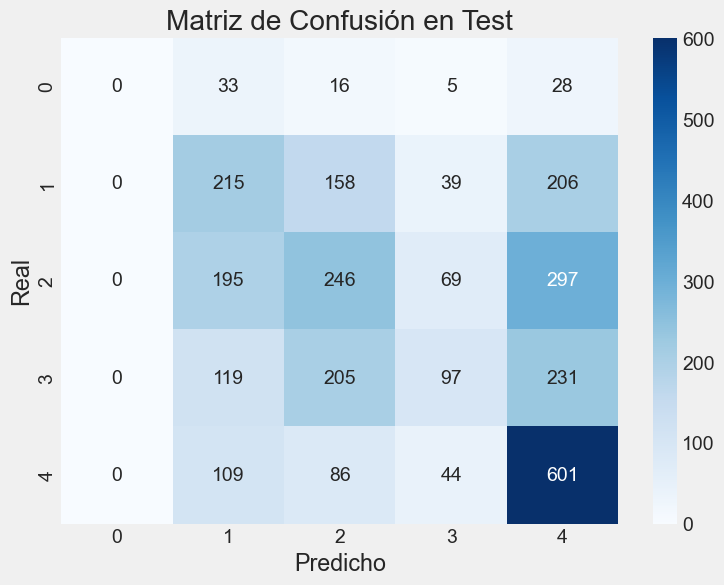

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Matriz de confusión para ver qué clases se confunden
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión en Test')
plt.show()